# Assignment for Linear Regression - by Nishu

### 1) Import the datasheet and define the data frame (df) using Pandas

In [1]:
import pandas as pd

# importing the csv file into a dataframe
df = pd.read_csv('alloy-confp-train-data.csv')

print(df.shape)
df.head()

(120, 8)


,ID,Al,Co,Cr,Cu,Fe,Ni,HV
0,1,0.058824,0.235294,0.235294,0.0,0.235294,0.235294,110
1,2,0.024390,0.243902,0.243902,0.0,0.243902,0.243902,118
2,4,0.090909,0.227273,0.227273,0.0,0.227273,0.227273,127
3,5,0.085714,0.228571,0.228571,0.0,0.228571,0.228571,131
4,7,0.000000,0.250000,0.250000,0.0,0.250000,0.250000,139


Checking the dataset for any missing values or issues before proceeding

In [2]:
# checking data info - dtypes and null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      120 non-null    int64  
 1   Al      120 non-null    float64
 2   Co      120 non-null    float64
 3   Cr      120 non-null    float64
 4   Cu      120 non-null    float64
 5   Fe      120 non-null    float64
 6   Ni      120 non-null    float64
 7   HV      120 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 7.6 KB


In [3]:
# basic statistics of the data
df.describe()

,ID,Al,Co,Cr,Cu,Fe,Ni,HV
count,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000,120.000000
mean,81.150000,0.175608,0.147627,0.185813,0.099436,0.177931,0.213585,434.608333
std,44.953318,0.113294,0.104673,0.090014,0.090318,0.078806,0.094755,187.126762
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,110.000000
25%,41.750000,0.100000,0.000000,0.147059,0.000000,0.146008,0.159062,247.250000
50%,81.000000,0.180653,0.166667,0.185185,0.083333,0.181818,0.212575,475.500000
75%,120.250000,0.230769,0.225000,0.233242,0.181818,0.222222,0.260000,576.000000
max,155.000000,0.461538,0.428571,0.555556,0.290000,0.468750,0.500000,775.000000


In [4]:
# checking for missing values and duplicates
print('Missing values:')
print(df.isnull().sum())
print()
print('Duplicate rows:', df.duplicated().sum())

Missing values:
ID    0
Al    0
Co    0
Cr    0
Cu    0
Fe    0
Ni    0
HV    0

Duplicate rows: 0


No missing values and no duplicates so we can proceed directly.

### 2) Separate the df columns into features (X_cols) and target property (y_cols)

In [5]:
# separating features and target
# ID is just an identifier so we skip it
# Al, Co, Cr, Cu, Fe, Ni are the metal concentrations (features)
# HV is hardness value (target)

X_cols = ['Al', 'Co', 'Cr', 'Cu', 'Fe', 'Ni']
y_cols = ['HV']

print('X_cols:', X_cols)
print('y_cols:', y_cols)

X_cols: ['Al', 'Co', 'Cr', 'Cu', 'Fe', 'Ni']
y_cols: ['HV']


### 3) Convert the feature columns and target property column into arrays (X and y) using NumPy

In [6]:
import numpy as np

# converting dataframe columns to numpy arrays
X = df[X_cols].to_numpy()
y = df[y_cols].to_numpy()

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (120, 6)
y shape: (120, 1)


### 4) Use LinearRegression() to fit X and y

In [7]:
from sklearn.linear_model import LinearRegression

# creating the model and fitting on our data
model = LinearRegression()
model.fit(X, y)

print('Model fitted successfully')

Model fitted successfully


### 5) Determine the RMSE and R2 score

In [8]:
from sklearn.metrics import root_mean_squared_error, r2_score

# predicting using the trained model
y_pred = model.predict(X)

# calculating rmse and r2
rmse = root_mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print('RMSE:', rmse)
print('R2 Score:', r2)

RMSE: 81.54039813380254
R2 Score: 0.8085267391840809


### 6) Determine the weights (coefficients) and the intercept

In [9]:
# getting the weights and intercept from the trained model
print('Weights (coef_):', model.coef_[0])
print('Intercept (intercept_):', model.intercept_[0])

Weights (coef_): [1150.262195549815, -284.75339303879184, 208.2268479268816, -159.08890106177392, -234.4465797207451, -680.2001694230469]
Intercept (intercept_): 438.77484349625064


### 7) Plot y vs y_pred

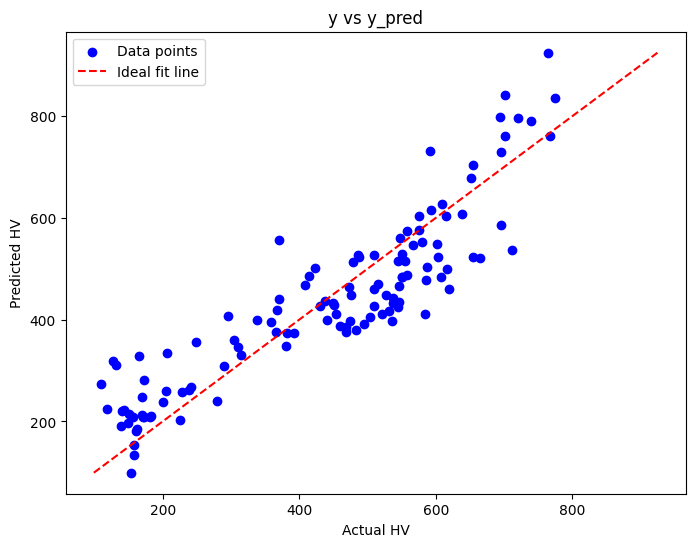

In [10]:
import matplotlib.pyplot as plt

# plotting actual values vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, color='blue', label='Data points')

# red dashed line for perfect prediction
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label='Ideal fit line')

plt.xlabel('Actual HV')
plt.ylabel('Predicted HV')
plt.title('y vs y_pred')
plt.legend()
plt.show()